# Credit Risk Scoring & Loan Approval System

## Business Understanding

### Key business questions

- Which borrowers are likely to default?
- How can borrowers be grouped into risk levels?
- What approval threshold should be used?
- What financial tradeoffs exist between risky approvals and rejected customers?
- Which factors contribute most to default risk?

### Main objectives

- Predict borrower default probability
- Build a credit risk scoring system
- Create risk-based borrower segmentation
- Develop loan approval decision logic
- Evaluate business and financial tradeoffs
- Improve interpretability using SHAP
- Assess fairness and bias
- Deploy an interactive Streamlit dashboard

### Problem type

- Binary classification problem

### Target variable

- `0` → No serious financial distress
- `1` → Serious financial distress within two years

### Modeling goal

Predict the probability of borrower default risk.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load training dataset
df = pd.read_csv(
    "/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv"
)

df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# Check dataset shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 150000
Columns: 12


In [4]:
# View column names
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [6]:
#Remove unnecessary column
df = df.drop(columns="Unnamed: 0")

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### Insights

- The dataset contains 150,000 borrower records and 12 columns.
- Most variables are numerical and related to credit usage, delinquency history, debt ratio, and borrowing behavior.
- The target variable is `SeriousDlqin2yrs`, which indicates whether a borrower experienced serious financial distress within two years.
- `MonthlyIncome` and `NumberOfDependents` contain missing values that will require preprocessing later.
- `Unnamed: 0` appears to be an index-like column and may not provide predictive value.

In [7]:
# Check target distribution
target_counts = df["SeriousDlqin2yrs"].value_counts()
target_percentages = (
    df["SeriousDlqin2yrs"]
    .value_counts(normalize=True) * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary

,Count,Percentage
SeriousDlqin2yrs,,
0,139974,93.32
1,10026,6.68


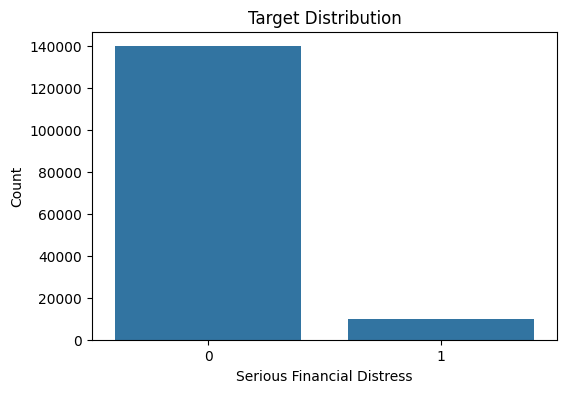

In [8]:
# Visualize target distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="SeriousDlqin2yrs"
)

plt.title("Target Distribution")
plt.xlabel("Serious Financial Distress")
plt.ylabel("Count")

plt.show()

### Insights

- The dataset is highly imbalanced.
- About 93.32% of borrowers did not experience serious financial distress.
- Only 6.68% belong to the default/high-risk class.
- This imbalance makes accuracy less reliable as a standalone evaluation metric.
- Later stages will focus more on recall, precision, probability calibration, and threshold tuning.